In [26]:
from os import getenv
from typing import TypedDict
from langchain_core.messages import SystemMessage, HumanMessage
from langchain_naver_community.tool import NaverNewsSearch
from langchain_openai import ChatOpenAI
from langgraph.graph import StateGraph, END
from langgraph.checkpoint.memory import InMemorySaver
from dotenv import load_dotenv
from dateutil import parser as dateparser
from typing import TypedDict, List, Dict, Any
from datetime import datetime
import json
import uuid

load_dotenv()

True

In [27]:
# create prompts/keys.py
# create prompts/registry.py
from enum import Enum
from pathlib import Path

class PromptKey(str, Enum):
    CATEGORIZE_NEWS = "categorize_news"
    BUILD_MACRO_REPORT = "build_macro_report"

# PROMPT_BASE_DIR = Path(__file__).parent / "prompts"
PROMPT_BASE_DIR = Path.cwd() / "prompts" # jupyter notebook

PROMPT_REGISTRY = {
    (PromptKey.CATEGORIZE_NEWS, "REV00") : PROMPT_BASE_DIR / "categorize_news.md",
    (PromptKey.BUILD_MACRO_REPORT, "REV00") : PROMPT_BASE_DIR / "build_macro_report.md",
}

def load_prompt(key: PromptKey, revision: str = "REV00") -> str:
    rel_path = PROMPT_REGISTRY.get((key, revision))
    if rel_path is None:
        raise KeyError(f"Prompt not found: key={key}")
    full_path = PROMPT_BASE_DIR / rel_path
    with open(full_path, "r", encoding="utf-8") as f:
        return f.read()



In [28]:
class NewsState(TypedDict):
    query: str                # 예: "미국 경제" / "연준" / "CPI"
    target_date: str          # "YYYY-MM-DD" 포맷 (예: "2025-03-20")
    raw_news: List[dict]      # NaverNewsSearch 원본 결과
    macro_news: List[dict]    # 날짜 + 거시경제 필터 후 기사
    categorized_news: Dict[str, Dict[str, Dict[str, List[dict]]]]  # 대/중/소
    report_markdown: str      # 최종 Markdown 리포트


In [29]:
def search_news_node(state: NewsState) -> dict:
    naver_news_search = NaverNewsSearch(
        display=100,
        # sort="date"
    )
    results = naver_news_search.run({
        "query" : state["query"],
        "target_date" : state["target_date"],
        "min_results" : 100,
    })

    # naver_news_search.run()이 str을 반환할 수 있음
    if isinstance(results, str):
        # 디버깅을 위해 에러 출력
        print("[NaverNewsSearch ERROR]", results)
        raise RuntimeError(f"NaverNewsSearch failed: {results}")
    
    return {"raw_news": results}


In [30]:
from keywords import keywords

def is_macro_related(text: str) -> bool:
    return any(kw in text for kw in keywords["MACRO_KEYWORDS"])

def is_us_centered(text: str) -> bool:
    return any(kw in text for kw in keywords["US_FOCUS_KEYWORDS"])


In [31]:
def filter_by_date_and_macro_node(state: NewsState) -> dict:
    target_date = state["target_date"]  # "YYYY-MM-DD"
    filtered = []

    for item in state.get("raw_news", []):
        pub = item.get("pubDate")
        if not pub:
            continue
        try:
            dt = dateparser.parse(pub)
            pub_date_str = dt.strftime("%Y-%m-%d")
        except Exception:
            continue

        if pub_date_str != target_date:
            continue

        text = (item.get("title", "") or "") + " " + (item.get("description", "") or "")

        # 1) 거시경제 관련
        if not is_macro_related(text):
            continue

        # 2) 미국 중심으로 필터링 (완전히 배제하면 안 되면, "가중치"용으로만 써도 됨)
        # 여기서는 "미국 관련 키워드가 있으면 우선 포함" 정도로 처리
        item["_us_focus"] = is_us_centered(text)

        filtered.append(item)

    # 미국 관련 기사가 있으면 그것들을 우선 사용하고,
    # 없으면 전체 filtered를 사용
    us_articles = [it for it in filtered if it.get("_us_focus")]
    macro_news = us_articles if us_articles else filtered

    return {"macro_news": macro_news}


In [32]:
def categorize_news_node(state: NewsState) -> dict:
    news_list = state.get("macro_news", [])
    if not news_list:
        return {"categorized_news": {}}

    items_for_prompt = []
    for idx, item in enumerate(news_list):
        items_for_prompt.append(
            {
                "id": idx,
                "title": item.get("title", ""),
                "description": item.get("description", ""),
            }
        )

    # Prompt loading
    system_prompt = load_prompt(PromptKey.CATEGORIZE_NEWS, "REV00")
    human_prompt = f"뉴스 기사 목록:\n{json.dumps(items_for_prompt, ensure_ascii=False, indent=2)}"

    resp = llm_categorizer.invoke(
        [SystemMessage(content=system_prompt),
         HumanMessage(content=human_prompt)]
    )

    try:
        categories = json.loads(resp.content)
    except Exception:
        return {"categorized_news": {}}

    categorized: Dict[str, Dict[str, Dict[str, List[dict]]]] = {}

    for cat in categories:
        idx = cat.get("id")
        if idx is None or idx >= len(news_list):
            continue
        major = cat.get("major", "기타") or "기타"
        middle = cat.get("middle", "기타") or "기타"
        minor = cat.get("minor", "기타") or "기타"

        categorized.setdefault(major, {}).setdefault(middle, {}).setdefault(minor, []).append(
            news_list[idx]
        )

    return {"categorized_news": categorized}


In [33]:
def build_markdown_report_node(state: NewsState) -> dict:
    categorized = state.get("categorized_news", {})
    query = state.get("query", "")
    target_date = state.get("target_date", "")
    
    # 리포트 헤더
    lines = []
    lines.append(f"# 글로벌 거시경제 데일리 리포트 (미국 중심)")
    lines.append("")
    lines.append(f"- 검색 키워드: **{query}**")
    lines.append(f"- 기준 날짜: **{target_date}**")
    lines.append(f"- 생성 시각: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
    lines.append("")
    lines.append("---")
    lines.append("")

    if not categorized:
        lines.append("> 해당 날짜에 조건을 만족하는 뉴스가 없습니다.")
        report = "\n".join(lines)
        return {"report_markdown": report}

    # 카테고리 순회
    for major, middle_dict in categorized.items():
        lines.append(f"## {major}")
        lines.append("")

        for middle, minor_dict in middle_dict.items():
            lines.append(f"### 지역: {middle}")
            lines.append("")

            for minor, articles in minor_dict.items():
                lines.append(f"#### 주제: {minor}")
                lines.append("")

                # 기사 텍스트 합치기
                texts = []
                for a in articles:
                    t = a.get("title", "")
                    d = a.get("description", "")
                    link = a.get("link", "")
                    if link:
                        texts.append(f"- **{t}**\n  - {d}\n  - [원문 보기]({link})")
                    else:
                        texts.append(f"- **{t}**\n  - {d}")
                joined_articles = "\n".join(texts)

                prompt = load_prompt(PromptKey.BUILD_MACRO_REPORT, "REV00")
                prompt = prompt.format(
                    major=major,
                    middle=middle,
                    minor=minor,
                    joined_articles=joined_articles
                )

                resp = llm.invoke(prompt)
                lines.append(resp.content.strip())
                lines.append("")
                lines.append("링크 : " + a.get("link", ""))
                lines.append("")
            lines.append("---")
            lines.append("")

    report = "\n".join(lines)
    return {"report_markdown": report}


In [34]:
from langgraph.graph import StateGraph, END

def build_graph():
    workflow = StateGraph(NewsState)

    workflow.add_node("search_news", search_news_node)
    workflow.add_node("filter_by_date_and_macro", filter_by_date_and_macro_node)
    workflow.add_node("categorize_news", categorize_news_node)
    workflow.add_node("build_markdown_report", build_markdown_report_node)

    workflow.set_entry_point("search_news")

    workflow.add_edge("search_news", "filter_by_date_and_macro")
    workflow.add_edge("filter_by_date_and_macro", "categorize_news")
    workflow.add_edge("categorize_news", "build_markdown_report")
    workflow.add_edge("build_markdown_report", END)

    app = workflow.compile()
    return app


In [35]:
def print_detailed_news_stats(final_state: dict):
    """
    final_state 구조를 기반으로 다음을 예쁘게 출력한다.
    1) 전체 뉴스 개수 및 비율
       - raw_news 개수
       - macro_news 개수
       - categorized_news에 실제로 포함된 기사 수
       - 전체 뉴스 대비 필터링 비율, 분류 비율
    2) 거시 카테고리 구조
       - 대분류별 중분류 개수
       - (대분류, 중분류)별 소분류 개수 및 기사 수
    """
    # 1. 기본 개수 계산
    raw_count = len(final_state.get("raw_news", []))
    macro_count = len(final_state.get("macro_news", []))
    categorized = final_state.get("categorized_news", {}) or {}

    # categorized 안에 실제 기사 수 세기
    categorized_article_count = 0
    for major_dict in categorized.values():
        for middle_dict in major_dict.values():
            for articles in middle_dict.values():
                categorized_article_count += len(articles)

    # 비율 계산 (0 나누기 방지)
    filter_ratio = (macro_count / raw_count * 100) if raw_count > 0 else 0.0
    classify_ratio = (categorized_article_count / raw_count * 100) if raw_count > 0 else 0.0

    print("\n==================== 뉴스 처리 통계 ====================")
    print("1) 전체 개수 및 비율")
    print("--------------------------------------------------------")
    print(f"{'Raw 뉴스 수':<30} : {raw_count:>5}건")
    print(f"{'거시 필터 후 뉴스 수(macro_news)':<30} : {macro_count:>5}건")
    print(f"{'분류에 사용된 기사 수(categorized)':<30} : {categorized_article_count:>5}건")
    print("--------------------------------------------------------")
    if raw_count > 0:
        print(f"{'필터링 비율 (macro / raw)':<30} : {filter_ratio:>6.2f}%")
        print(f"{'분류 비율 (categorized / raw)':<30} : {classify_ratio:>6.2f}%")
    else:
        print("원본 뉴스(raw_news)가 0건이어서 비율 계산 불가")
    print("========================================================\n")

    # 2. 카테고리 구조 통계
    print("2) 거시 카테고리 구조")
    print("--------------------------------------------------------")
    if not categorized:
        print("categorized_news가 비어 있습니다.")
        print("========================================================\n")
        return

    for major, middle_dict in categorized.items():
        middle_count = len(middle_dict)
        print(f"[대분류] {major} (중분류 {middle_count}개)")
        
        for middle, minor_dict in middle_dict.items():
            minor_count = len(minor_dict)
            # 이 중분류에 포함된 기사 수
            middle_article_count = sum(len(articles) for articles in minor_dict.values())
            print(f"  ├─ [중분류] {middle} (소분류 {minor_count}개, 기사 {middle_article_count}건)")
            
            for minor, articles in minor_dict.items():
                minor_article_count = len(articles)
                print(f"  │     ├─ [소분류] {minor} (기사 {minor_article_count}건)")
        print("--------------------------------------------------------")
    print("========================================================\n")


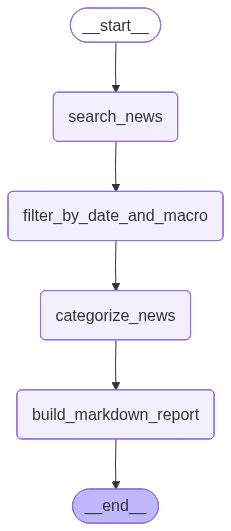

In [36]:
from IPython.display import Image, display
from langchain_core.runnables.graph import CurveStyle, MermaidDrawMethod, NodeStyles

app = build_graph()

display(
    Image(
        app.get_graph().draw_mermaid_png(
            draw_method=MermaidDrawMethod.API,
        )
    )
)

In [37]:
model_name = "tngtech/deepseek-r1t2-chimera:free"
openrouter_url = "https://openrouter.ai/api/v1"

llm = ChatOpenAI(
    model=model_name,
    api_key=getenv("OPENROUTER_API_KEY"),
    base_url=openrouter_url,
)

llm_categorizer = ChatOpenAI(
    model=model_name,
    api_key=getenv("OPENROUTER_API_KEY"),
    base_url=openrouter_url,
    temperature=0,
)

date = "2025-11-21" # 관심 날짜

initial_state: NewsState = {
    "query": "미국 주식",        # 키워드
    "target_date": date,
    "raw_news": [],
    "macro_news": [],
    "categorized_news": {},
    "report_markdown": "",
}

final_state = app.invoke(initial_state)

report_md = final_state["report_markdown"]
print(report_md)  # 콘솔 확인

file_name = f"./daily_reports/daily_report_{date}.md"

with open(file_name, "w", encoding="utf-8") as f:
    f.write(report_md)


# 글로벌 거시경제 데일리 리포트 (미국 중심)

- 검색 키워드: **미국 주식**
- 기준 날짜: **2025-11-21**
- 생성 시각: 2025-11-23 19:54:15

---

## 금융시장·리스크

### 지역: 미국

#### 주제: 주식시장 붕괴

[개요]  
- 142년 주기로 반복되는 전쟁과 경제 위기 패턴을 분석한 연구가 주목받고 있으며, 1929년 미국 주식시장 붕괴 사례가 대표적인 사례로 재조명되고 있습니다.  
- 역사적 사이클 연구의 선구자인 에드워드 듀이의 이론은 당시 체계화되지 않았던 '경제주기' 개념을 정립하는 데 기여했으며, 현재 금융시장 리스크 관리에 활용되고 있습니다.  
- 연구진은 과거 데이터를 바탕으로 주식시장 붕괴·경기침체 등 거시적 리스크 예측에 사이클 분석을 적용하고 있으며, 이는 향후 시장 변동성 대비 전략 수립에 영향을 줄 것으로 전망됩니다.  

[미국 시사점]  
- **역사적 패턴 인식 강화**: 경기순환이론 기반 장기적 시장 리스크 평가 수요 증가 및 정책 당국의 선제적 모니터링 강화 가능성  
- **투자 심리 악화 요인**: 사이클론념 확산으로 단기 시장 과열 또는 조정 국면에서의 과도한 공포 심리 유발 우려  
- **규제 프레임워크 진화**: 1929년 대공황 이후 강화된 금융안정장치(예: FDIC)와 유사한 차세대 시스템 도입 논의 가속화 전망  

[글로벌 자산군 영향]  
- **주식**: 사이클 하방국면 전망 확대 시 변동성 급증(VIX 상승) 및 테마별 편차 확대 (방어주↑ vs. 글로벌 사이클릭주↓)  
- **채권**: 안전자산 수요 증가로 미국 장기물 채권 금리 하락 압력 (+기준금리 인하 기대 반영)  
- **환율**: 달러화의 긴급 안전자산(status) 강화로 신흥국 통화 대비 절상 가능성  
- **원자재**: 경제 침체 우려로 산업원자재(구리 등) 가격 하락 vs. 금의 헤지 수요 증가 양극화

링크 : https://n.news.naver.com/mnews/art

In [38]:
print_detailed_news_stats(final_state)


==================== 뉴스 처리 통계 ====================
1) 전체 개수 및 비율
--------------------------------------------------------
Raw 뉴스 수                       :   100건
거시 필터 후 뉴스 수(macro_news)       :    58건
분류에 사용된 기사 수(categorized)      :    58건
--------------------------------------------------------
필터링 비율 (macro / raw)           :  58.00%
분류 비율 (categorized / raw)      :  58.00%

2) 거시 카테고리 구조
--------------------------------------------------------
[대분류] 금융시장·리스크 (중분류 4개)
  ├─ [중분류] 미국 (소분류 9개, 기사 13건)
  │     ├─ [소분류] 주식시장 붕괴 (기사 1건)
  │     ├─ [소분류] AI 거품론 (기사 3건)
  │     ├─ [소분류] 외국인 매도세 (기사 1건)
  │     ├─ [소분류] 주식시장 급락 (기사 1건)
  │     ├─ [소분류] 자산 고평가 경고 (기사 1건)
  │     ├─ [소분류] 외국인 대규모 매도 (기사 3건)
  │     ├─ [소분류] 주식 포트폴리오 (기사 1건)
  │     ├─ [소분류] 신용거래 리스크 (기사 1건)
  │     ├─ [소분류] 밸류에이션 투자 (기사 1건)
  ├─ [중분류] 글로벌 (소분류 11개, 기사 17건)
  │     ├─ [소분류] 주식시장 급락 (기사 2건)
  │     ├─ [소분류] AI 주식 거품론 (기사 1건)
  │     ├─ [소분류] 고평가 주식 매도 (기사 1건)
  │     ├─ [소분류] 위험자산 하락 (기사 2건)
  │     ├─ [소분류] 암